<h1 style="text-align: center; color: darkblue;">Experiments Dashboard</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [4. Load, Filter & Aggregate Experiments](#4)
5. [Results on Test set](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we’ll explore and visualize the results from multiple experiments to identify performance patterns across models and configurations. The goal is to gain insights such as which model families (e.g., decision trees, random forests, neural networks) tend to perform best, and which hyperparameter ranges or combinations lead to consistently strong results. Through comparative plots and summary statistics, we’ll look for trends that can guide future model selection and tuning strategies.


## <a id="2" style="color: darkred; text-decoration: none;"> 2. Setup </a>

In [1]:
import mlflow
import pandas as pd

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

print(mlflow_path)
print(f"sqlite:///{mlflow_path}")

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlflow.db
sqlite:////home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlflow.db


In [3]:
EXPERIMENT_NAME = "network_security"

## <a id="3" style="color: darkred; text-decoration: none;"> 3. Helper Functions </a>

In [4]:
def aggregate_rows(df, param_cols, metric_cols, verbose=True):
    # Safe guard: trim column name whitespace (very common source of bugs)
    df.columns = df.columns.str.strip()
    
    # How many unique parameter combinations and duplicates?
    counts = df.groupby(param_cols, dropna=False).size().reset_index(name='count')

    if verbose:
        print("Unique parameter combos:", counts.shape[0])
        print("Groups with duplicates (>1):")
        print(counts[counts['count'] > 1])
    
    # Aggregate metrics (mean) for each unique param combination
    grouped_metrics = (
        df.groupby(param_cols, dropna=False)[metric_cols]
          .mean()
          .reset_index()
    )
    
    # For the remaining columns, take the first occurrence for each param combo
    other_cols = [c for c in df.columns if c not in param_cols + metric_cols]
    grouped_first = (
        df.groupby(param_cols, dropna=False)[other_cols]
          .first()
          .reset_index()
    )
    
    # Merge back together -> one row per unique parameter combination
    result = pd.merge(grouped_metrics, grouped_first, on=param_cols, how='left')

    
    if verbose:
        print("Original rows:", len(df))
        print("Rows after merging duplicates:", len(result))


    return result


In [5]:
#Visualize performance vs hyperparameters
def plot_f1_vs_hparams(df, model_type, hyperparams, hue=None, size=None):
    """
    Plot F1 vs each hyperparameter for a given model type.
    
    Args:
        df (pd.DataFrame): Results DataFrame.
        model_type (str): Filter by model type in 'tags.model_type'.
        hyperparams (list): List of hyperparameter column names.
        hue (str, optional): Column to use for color encoding.
        size (str, optional): Column to use for point size encoding.
    """
    sub = df[df['tags.model_type'] == model_type].copy()
    sub['metrics.f1'] = pd.to_numeric(sub['metrics.f1'], errors='coerce')
    
    n = len(hyperparams)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, hp in enumerate(hyperparams):
        sub[hp] = pd.to_numeric(sub[hp], errors='coerce')
        sns.scatterplot(
            data=sub,
            x=hp,
            y='metrics.f1',
            hue=hue,
            size=size,
            palette='viridis',
            ax=axes[i],
            alpha=0.8
        )
        axes[i].set_title(f"{model_type.upper()} – F1 vs {hp.split('.')[-1]}")
        axes[i].set_xlabel(hp.split('.')[-1])
        axes[i].set_ylabel("F1 Score")

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [6]:
# f1 plot bar
def plot_f1_bar(df, x, hue="tags.model_type", title=None):
    """
    Bar plot of F1 vs categorical hyperparameter, grouped by model type or another hue.
    
    Args:
        df (pd.DataFrame): Results DataFrame.
        x (str): Column name for x-axis (e.g., 'params.val_size', 'params.balance_factor').
        hue (str): Column to use for color grouping (default: 'tags.model_type').
        title (str, optional): Plot title.
    """
    df = df.copy()
    df['metrics.f1'] = pd.to_numeric(df['metrics.f1'], errors='coerce')
    df[x] = df[x].astype(str)  # Treat as categorical for clearer x-axis

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df,
        x=x,
        y="metrics.f1",
        hue=hue,
        palette="viridis",
        errorbar="sd"
    )
    plt.title(title or f"F1 Score by {x.split('.')[-1]} and {hue.split('.')[-1]}")
    plt.xlabel(x.split('.')[-1])
    plt.ylabel("F1 Score")
    plt.tight_layout()
    plt.show()


In [7]:
# plot metrics
def plot_model_metrics(df, id_vars=None):
    """
    Visualize performance metrics by model type.

    This function reshapes the given DataFrame from wide to long format,
    detecting all metric columns automatically (those starting with "metrics.").
    It then creates a grouped bar plot showing each model type’s performance
    across different metrics.

    Args:
        df (pd.DataFrame): DataFrame containing experiment results and metrics.
        id_vars (list[str], optional): Columns to keep fixed during the melt operation.
            Defaults to ["tags.model_type", "params.val_size", "params.balance_factor"].

    Returns:
        None: Displays a seaborn bar plot.
    """
    
    df = df.copy()

    # Default grouping columns
    if id_vars is None:
        id_vars = ["tags.model_type", "params.val_size", "params.balance_factor"]

    # Detect all metric columns automatically
    metric_cols = [c for c in df.columns if c.startswith("metrics.")]

    # Melt metrics into long format
    melted = df.melt(
        id_vars=[c for c in id_vars if c in df.columns],
        value_vars=metric_cols,
        var_name="metric",
        value_name="value"
    )

    # Clean metric names
    melted["metric"] = melted["metric"].str.replace("metrics.", "", regex=False)

    # Plot
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=melted,
        x="tags.model_type",
        y="value",
        hue="metric",
        palette="viridis"
    )
    plt.title("Performance Metrics by Model Type")
    plt.xlabel("Model Type")
    plt.ylabel("Metric Value")
    plt.tight_layout()
    plt.show()

## <a id="4" style="color: darkred; text-decoration: none;"> 4. Load, Filter & Aggregate Experiments </a>

In [32]:
df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME]) 
df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,...,params.optimizer,tags.data_version,tags.mlflow.source.type,tags.tuning_run_id,tags.dataset,tags.mlflow.source.git.commit,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.model_type
0,1b53e4070f004edf88c8bb9763169232,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:04:18.799000+00:00,2025-11-13 21:04:19.564000+00:00,0.998101,0.998101,0.998106,0.998101,...,None,v1,LOCAL,9699918508f84749b1fdf6f873e09d8e,test,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,test_evaluation,None
1,c6076b201223475a82b2f4ddd7f6d50a,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:51.675000+00:00,2025-11-13 21:03:52.433000+00:00,0.998101,0.998101,0.998106,0.998101,...,None,v1,LOCAL,9699918508f84749b1fdf6f873e09d8e,test,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,test_evaluation,None
2,9699918508f84749b1fdf6f873e09d8e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:39.359000+00:00,2025-11-13 21:03:41.900000+00:00,0.997435,0.997413,0.997471,0.997413,...,None,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,tree
3,2d3e3ba6c2224f5ea82bf12d2cc3c5c0,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:32.408000+00:00,2025-11-13 21:03:35.112000+00:00,0.956442,0.938232,0.980126,0.938232,...,None,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,tree
4,680fdb28a27247fd9a274213c0ce9761,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:14.106000+00:00,2025-11-13 21:03:20.008000+00:00,0.965352,0.959902,0.975006,0.959902,...,Adam,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,nn
5,5350dbd1648e4292a32a4be9c228f258,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:14.086000+00:00,2025-11-13 21:03:20.061000+00:00,0.963093,0.956018,0.974218,0.956018,...,Adam,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,nn
6,03f37bb3eda848c7b6f4aa7d95129653,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:01:44.063000+00:00,2025-11-13 21:01:44.813000+00:00,0.979189,0.969608,0.990970,0.969608,...,None,v1,LOCAL,4f59bf443e654549978f87afb13c45b9,test,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,test_evaluation,None
7,45a35fe1644443479085856831fe28e1,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:01:01.957000+00:00,2025-11-13 21:01:07.239000+00:00,0.958074,0.949939,0.971118,0.949939,...,Adam,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,nn
8,4f59bf443e654549978f87afb13c45b9,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:00:50.612000+00:00,2025-11-13 21:00:54.612000+00:00,0.981017,0.971994,0.992019,0.971994,...,None,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,tree
9,87994869cd1a468eb708478239e6be72,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 20:59:36.462000+00:00,2025-11-13 20:59:37.236000+00:00,0.957209,0.948817,0.969817,0.948817,...,None,v1,LOCAL,5486025d0f074000b6adc769b9bc433f,test,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,test_evaluation,None


In [9]:
df.shape

(11, 35)

In [10]:
df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.f1', 'metrics.recall', 'metrics.precision',
       'metrics.accuracy', 'params.model_type', 'params.criterion',
       'params.balance_factor', 'params.val_shape', 'params.min_samples_split',
       'params.train_shape', 'params.max_depth', 'params.val_size',
       'params.early_stop', 'params.final_lr', 'params.lr',
       'params.scaler_type', 'params.hidden1', 'params.hidden2',
       'params.batch_size', 'params.optimizer', 'tags.data_version',
       'tags.mlflow.source.type', 'tags.tuning_run_id', 'tags.dataset',
       'tags.mlflow.source.git.commit', 'tags.mlflow.source.name',
       'tags.mlflow.user', 'tags.mlflow.runName', 'tags.model_type'],
      dtype='object')

In [11]:
aux = df.iloc[2]
aux

run_id                                            9699918508f84749b1fdf6f873e09d8e
experiment_id                                                                    1
status                                                                    FINISHED
artifact_uri                     /home/marcos/Escritorio/AI-prod/AI-Driven-Netw...
start_time                                        2025-11-13 21:03:39.359000+00:00
end_time                                          2025-11-13 21:03:41.900000+00:00
metrics.f1                                                                0.997435
metrics.recall                                                            0.997413
metrics.precision                                                         0.997471
metrics.accuracy                                                          0.997413
params.model_type                                                             None
params.criterion                                                           entropy
para

**Filter by Tuning runs**

In [12]:
# Filter by run name and data version
df_tuning = df[
    (df["tags.mlflow.runName"] == "Tuning") &
    (df["tags.data_version"] == "v1")
]

**Filter by good results**

In [13]:
# Let's also filter by metric threshold
df_good = df_tuning[df_tuning["metrics.f1"] > 0.8]

# Inspect
df_good.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,...,params.optimizer,tags.data_version,tags.mlflow.source.type,tags.tuning_run_id,tags.dataset,tags.mlflow.source.git.commit,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.model_type
2,9699918508f84749b1fdf6f873e09d8e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:39.359000+00:00,2025-11-13 21:03:41.900000+00:00,0.997435,0.997413,0.997471,0.997413,...,None,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,tree
3,2d3e3ba6c2224f5ea82bf12d2cc3c5c0,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:32.408000+00:00,2025-11-13 21:03:35.112000+00:00,0.956442,0.938232,0.980126,0.938232,...,None,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,tree
4,680fdb28a27247fd9a274213c0ce9761,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:14.106000+00:00,2025-11-13 21:03:20.008000+00:00,0.965352,0.959902,0.975006,0.959902,...,Adam,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,nn
5,5350dbd1648e4292a32a4be9c228f258,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:03:14.086000+00:00,2025-11-13 21:03:20.061000+00:00,0.963093,0.956018,0.974218,0.956018,...,Adam,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,nn
7,45a35fe1644443479085856831fe28e1,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-13 21:01:01.957000+00:00,2025-11-13 21:01:07.239000+00:00,0.958074,0.949939,0.971118,0.949939,...,Adam,v1,LOCAL,None,None,ccd5e6f568cb5bba19aa251137817dd7023bfe7d,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,marcos,Tuning,nn


**Keep only relevant columns for the analysis**

In [14]:
# keep only relevant columns
columns_to_keep = [
       'start_time',
       'end_time', 
       'metrics.f1', 
       'metrics.recall', 
       'metrics.precision',
       'metrics.accuracy', 
       'params.criterion', 
       'params.max_depth', 
       'params.balance_factor',
       'params.val_size', 
       'params.min_samples_split', 
       'params.scaler_type', 
       'params.optimizer', 
       'params.early_stop',
       'params.hidden1', 
       'params.batch_size', 
       'params.lr', 
       'params.hidden2',
       'params.final_lr', 
       'tags.data_version',
       'tags.model_type']

df_good = df_good[columns_to_keep]

df_good.columns

Index(['start_time', 'end_time', 'metrics.f1', 'metrics.recall',
       'metrics.precision', 'metrics.accuracy', 'params.criterion',
       'params.max_depth', 'params.balance_factor', 'params.val_size',
       'params.min_samples_split', 'params.scaler_type', 'params.optimizer',
       'params.early_stop', 'params.hidden1', 'params.batch_size', 'params.lr',
       'params.hidden2', 'params.final_lr', 'tags.data_version',
       'tags.model_type'],
      dtype='object')

In [15]:
df_good.head()

,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,params.criterion,params.max_depth,params.balance_factor,params.val_size,...,params.scaler_type,params.optimizer,params.early_stop,params.hidden1,params.batch_size,params.lr,params.hidden2,params.final_lr,tags.data_version,tags.model_type
2,2025-11-13 21:03:39.359000+00:00,2025-11-13 21:03:41.900000+00:00,0.997435,0.997413,0.997471,0.997413,entropy,16,0.2,0.1,...,None,None,None,None,None,None,None,None,v1,tree
3,2025-11-13 21:03:32.408000+00:00,2025-11-13 21:03:35.112000+00:00,0.956442,0.938232,0.980126,0.938232,gini,6,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
4,2025-11-13 21:03:14.106000+00:00,2025-11-13 21:03:20.008000+00:00,0.965352,0.959902,0.975006,0.959902,None,None,0.2,0.1,...,standard,Adam,-1,64,32,0.00018554861285871894,64,0.00018554861285871894,v1,nn
5,2025-11-13 21:03:14.086000+00:00,2025-11-13 21:03:20.061000+00:00,0.963093,0.956018,0.974218,0.956018,None,None,0.2,0.2,...,standard,Adam,-1,256,32,0.00035540488329981114,64,0.00035540488329981114,v1,nn
7,2025-11-13 21:01:01.957000+00:00,2025-11-13 21:01:07.239000+00:00,0.958074,0.949939,0.971118,0.949939,None,None,0.2,0.2,...,standard,Adam,-1,64,64,0.00025721987933727833,128,0.00025721987933727833,v1,nn


**Aggregation**

Note that we can have different rows with the same configuration. That can happen because we ran the same experiment at different times. Let’s check that:

In [16]:
# check for duplicates
df = df_good


cols = [
    'params.criterion', 'params.max_depth', 'params.balance_factor',
    'params.val_size', 'params.min_samples_split', 'params.scaler_type',
    'params.optimizer', 'params.hidden1', 'params.batch_size',
    'params.lr', 'params.hidden2', 'tags.data_version', 'tags.model_type'
]

# Find duplicate configurations
duplicates = df[df.duplicated(subset=cols, keep=False)].sort_values(by=cols)

duplicates

,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,params.criterion,params.max_depth,params.balance_factor,params.val_size,...,params.scaler_type,params.optimizer,params.early_stop,params.hidden1,params.batch_size,params.lr,params.hidden2,params.final_lr,tags.data_version,tags.model_type


Indeed, we have duplicates.

In general, Running the same model/config multiple times can yield slightly different metrics due to:

- Random initialization (for neural networks).

- Non-deterministic operations.

- Data shuffling or randomness in training.

- Others


Averaging provides a more stable estimate of the expected performance for each configuration. We’ll do that.

**Note:** We can also compute the standard deviation to assess variability.



    

In [17]:
metric_cols = ["metrics.recall", "metrics.accuracy", "metrics.f1", "metrics.precision"]

result = aggregate_rows(df, cols, metric_cols, verbose=True)

Unique parameter combos: 7
Groups with duplicates (>1):
Empty DataFrame
Columns: [params.criterion, params.max_depth, params.balance_factor, params.val_size, params.min_samples_split, params.scaler_type, params.optimizer, params.hidden1, params.batch_size, params.lr, params.hidden2, tags.data_version, tags.model_type, count]
Index: []
Original rows: 7
Rows after merging duplicates: 7


In [18]:
result

,params.criterion,params.max_depth,params.balance_factor,params.val_size,params.min_samples_split,params.scaler_type,params.optimizer,params.hidden1,params.batch_size,params.lr,...,tags.data_version,tags.model_type,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,start_time,end_time,params.early_stop,params.final_lr
0,entropy,16,0.2,0.1,8,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997413,0.997413,0.997435,0.997471,2025-11-13 21:03:39.359000+00:00,2025-11-13 21:03:41.900000+00:00,None,None
1,gini,6,0.2,0.2,8,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.938232,0.938232,0.956442,0.980126,2025-11-13 21:03:32.408000+00:00,2025-11-13 21:03:35.112000+00:00,None,None
2,log_loss,8,0.2,0.2,5,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.971994,0.971994,0.981017,0.992019,2025-11-13 21:00:50.612000+00:00,2025-11-13 21:00:54.612000+00:00,None,None
3,NaN,NaN,0.2,0.1,NaN,standard,Adam,64,32,0.00018554861285871894,...,v1,nn,0.959902,0.959902,0.965352,0.975006,2025-11-13 21:03:14.106000+00:00,2025-11-13 21:03:20.008000+00:00,-1,0.00018554861285871894
4,NaN,NaN,0.2,0.2,NaN,standard,Adam,256,32,0.00035540488329981114,...,v1,nn,0.956018,0.956018,0.963093,0.974218,2025-11-13 21:03:14.086000+00:00,2025-11-13 21:03:20.061000+00:00,-1,0.00035540488329981114
5,NaN,NaN,0.2,0.2,NaN,standard,Adam,256,32,0.006647884757923017,...,v1,nn,0.949680,0.949680,0.956917,0.968573,2025-11-13 20:59:06.212000+00:00,2025-11-13 20:59:12.949000+00:00,-1,0.006647884757923017
6,NaN,NaN,0.2,0.2,NaN,standard,Adam,64,64,0.00025721987933727833,...,v1,nn,0.949939,0.949939,0.958074,0.971118,2025-11-13 21:01:01.957000+00:00,2025-11-13 21:01:07.239000+00:00,-1,0.00025721987933727833


## <a id="5" style="color: darkred; text-decoration: none;"> 5. Hyperparameter space analysis </a>


### Goal

Identify patterns like:

- For trees: higher max_depth + small min_samples_split yields better recall.

- For NNs: lr between 1e-3 and 1e-4 with batch_size=32 performs best.


**Split by model type**

In [19]:
# split by model type
models = df['tags.model_type'].unique()
for m in models:
    print(f"\n=== {m.upper()} ===")
    display(df[df['tags.model_type'] == m][['metrics.f1', 'metrics.recall', 'metrics.precision', 'metrics.accuracy']].describe())


=== TREE ===


,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
count,3.000000,3.000000,3.000000,3.000000
mean,0.978298,0.969213,0.989872,0.969213
std,0.020632,0.029689,0.008870,0.029689
min,0.956442,0.938232,0.980126,0.938232
25%,0.968729,0.955113,0.986073,0.955113
50%,0.981017,0.971994,0.992019,0.971994
75%,0.989226,0.984704,0.994745,0.984704
max,0.997435,0.997413,0.997471,0.997413



=== NN ===


,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
count,4.000000,4.000000,4.000000,4.000000
mean,0.960859,0.953885,0.972229,0.953885
std,0.004020,0.004967,0.002959,0.004967
min,0.956917,0.949680,0.968573,0.949680
25%,0.957785,0.949874,0.970482,0.949874
50%,0.960584,0.952978,0.972668,0.952978
75%,0.963658,0.956989,0.974415,0.956989
max,0.965352,0.959902,0.975006,0.959902


**Top-performing runs per model**

In [20]:
# Identify top-performing runs per model type
top_per_model = (
    df.loc[df.groupby('tags.model_type')['metrics.f1'].idxmax(),
           ['tags.model_type', 'metrics.f1', 'metrics.recall', 'metrics.precision', 'metrics.accuracy']]
)
top_per_model

,tags.model_type,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
4,nn,0.965352,0.959902,0.975006,0.959902
2,tree,0.997435,0.997413,0.997471,0.997413


**NN -> F1 vs hyperparams**

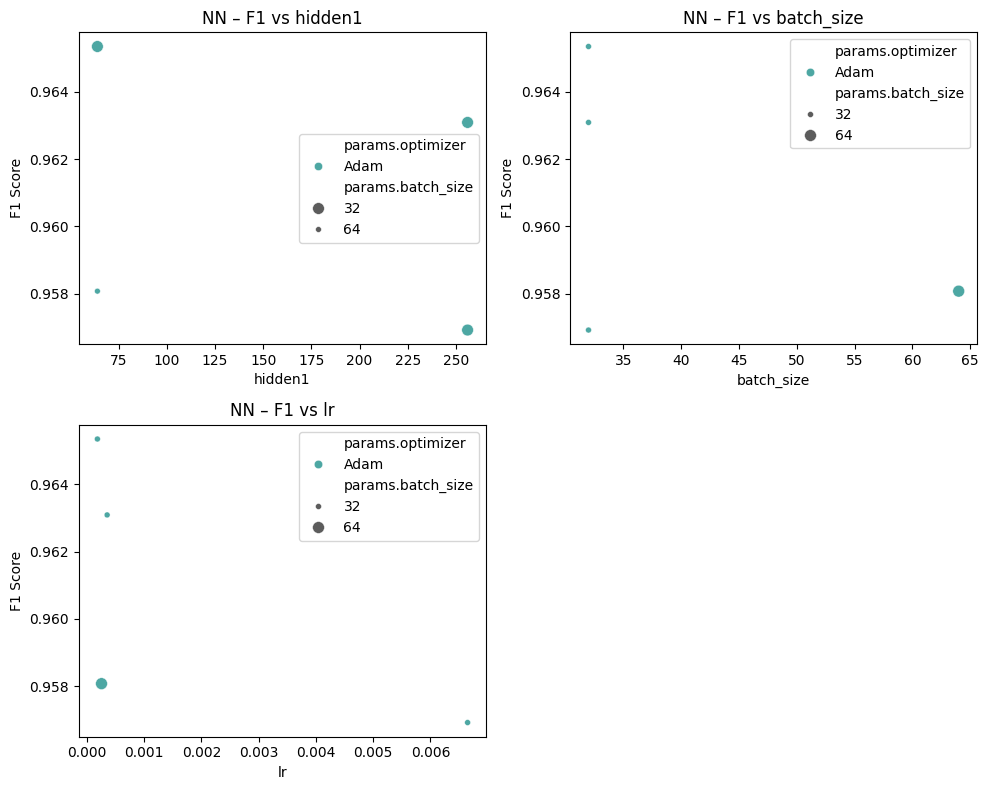

In [21]:
# NN -> f1 vs hyperparams
plot_f1_vs_hparams(
    result,
    model_type='nn',
    hyperparams=['params.hidden1', 'params.batch_size', 'params.lr'],
    hue='params.optimizer',
    size='params.batch_size'
)


Analysis.............

**Tree -> F1 vs hyperparams**

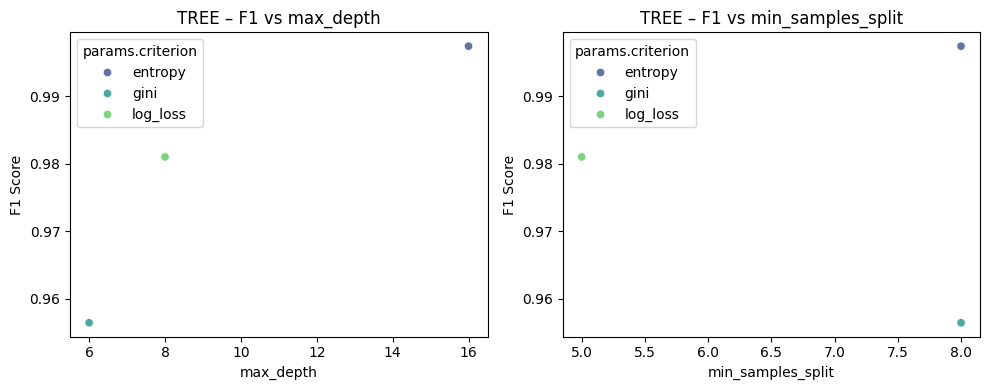

In [22]:
# Tree -> f1 vs hyperparams
plot_f1_vs_hparams(
    df,
    model_type='tree',
    hyperparams=['params.max_depth', 'params.min_samples_split'],
    hue='params.criterion',
)


**F1 by val size and model type**

Analysis...........

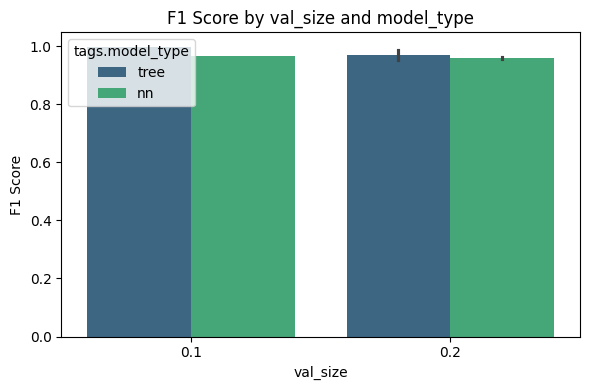

In [23]:
plot_f1_bar(df, x="params.val_size")

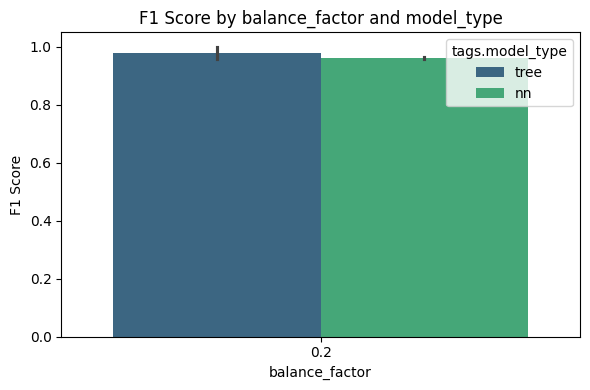

In [24]:
plot_f1_bar(df, x="params.balance_factor", hue="tags.model_type")

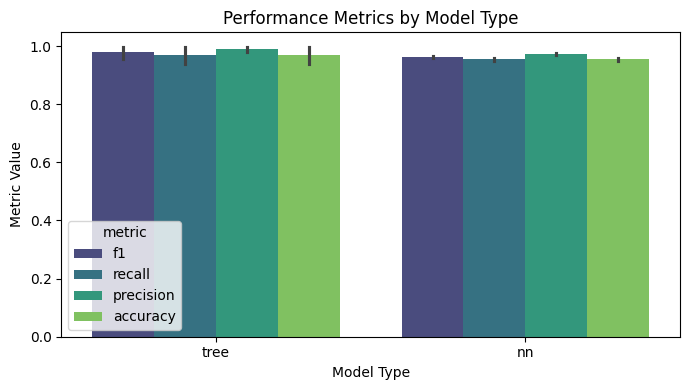

In [25]:
plot_model_metrics(df) # gropuing byu balance factor and model type

Conclusions

Recommended Order

Performance metrics by model
→ Gives an overall sense of which model families (Tree, NN, etc.) perform best on average.
(broad overview first)

F1 by validation size and model type
→ Shows how model performance scales with different validation splits.

F1 by balance factor and model type
→ Examines how handling class imbalance affects each model family.

Tree → F1 vs hyperparameters
→ Deep dive into what drives performance for tree models.

NN → F1 vs hyperparameters
→ Same idea, but for neural networks.

Top-performing runs per model
→ Finish by highlighting the best individual configurations.
(conclusion: what actually worked best)

That order tells a coherent story:

“Which model types perform best overall?”

“How does performance change with dataset setup?”

“What hyperparameters matter?”

“Which runs are the champions?”

1️⃣ Performance Overview

Goal: Compare overall performance across model families.
(High-level view to identify which model types stand out.)

Plot: Performance metrics by model type

2️⃣ Data Configuration Impact

Goal: Understand how data-related factors affect performance.

Plots:


F1 by validation size and model type

F1 by balance factor and model type

3️⃣ Hyperparameter Space Analysis

Goal: Identify performance patterns across hyperparameter configurations.

Examples of patterns to look for:

For trees: higher max_depth + smaller min_samples_split improves recall.

For NNs: learning rate between 1e-3 and 1e-4 with batch_size=32 performs best.
Plots:

Tree → F1 vs hyperparameters

NN → F1 vs hyperparameters

4️⃣ Top Performing Configurations

Goal: Highlight the best runs per model type for deeper inspection.

Table or bar plot: Top-performing runs per model

This flow reads naturally:

Overall → Data factors → Hyperparams → Winners

A good main section title should be broad enough to cover everything in the notebook, but still descriptive. Since this notebook focuses on experiment exploration, model performance, and hyperparameter insights, here are a few strong options:

Experiment Analysis ✅ – simple, clear, professional

Model Performance Exploration – emphasizes metrics and comparisons

Hyperparameter and Model Insights – highlights both performance and tuning

Experiment Dashboard – if you want to align with the “dashboard” style